## Simulazione Esame di Metodi Numerici per l'Intelligenza Artificiale


# Esercizio 1
Nel file test2.mat sono memorizzate le matrici ed i termini noti di 3 sistemi lineari:
        
        A x=b
        A1 x1 =b2
        A2 x2= b2
  
- Per ciascuno di essi, analizzando le caratteristiche delle matrici, individuare il metodo più adatto   **[punti 2]**
- Implementare i metodi e risolvere i tre sistemi lineari. **[punti 5]**
- Risolvere il secondo e terzo sistema  lineare con termine noto perturbato, ottenuto perturbando dello 0.1% la componente 0-esima del termine noto esatto. Calcolare l'errore relativo sui dati e l'errore relativo sulla soluzione e giustificare teoricamente facendo riferimento alle nozioni teoriche relative. **[punti 4]**


Totale **11 punti**




Per la lettura dei dati procedere nel seguente modo:

``from scipy.io import loadmat``

``import numpy as np``

``dati = loadmat('test2.mat')``

``A=dati["A"] ``

``A=A.astype(float)``

`` b=dati["b"] ``

`` b=b.astype(float)``

``A1=dati["A1"] ``

``A1=A1.astype(float)``

`` b1=dati["b1"] ``

`` b1=b1.astype(float)``

``A2=dati["A2"] ``

``A2=A2.astype(float)``

`` b2=dati["b2"] ``

`` b2=b2.astype(float)``


 

Informazioni matrice  A
Dimensioni:  (600, 600)
Simmetrica?  False
Definita positiva?  True
Condizionamento:  3.5346366016155746
raggio spettrale jacobi 0.17308978590878715


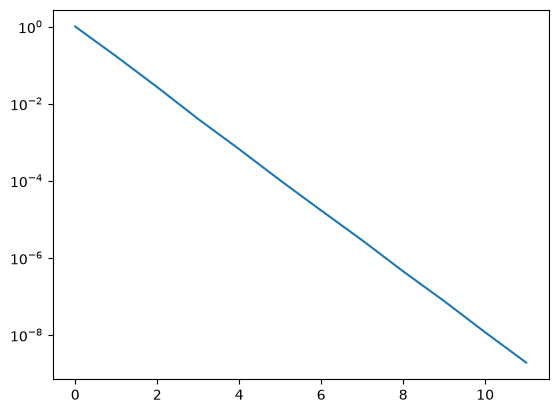

Informazioni matrice  A1
Dimensioni:  (30, 30)
Simmetrica?  True
Definita positiva?  True
Condizionamento:  1.2500000000000016
Errore soluzioni:  0.00020265829393389815
Errore dati:  0.00018242115886178654
Informazioni matrice  A2
Dimensioni:  (30, 30)
Simmetrica?  False
Definita positiva?  False
Condizionamento:  19999.99999997743
Errore soluzione:  0.3872795395555665
Errore dati:  0.00016849523005011145


In [ ]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import SolveTriangular as st
import scipy.linalg as spl

# Lettura dati fornita
dati = loadmat('test2.mat')
A=dati["A"] 
A=A.astype(float)
b=dati["b"] 
b=b.astype(float)
A1=dati["A1"] 
A1=A1.astype(float)
b1=dati["b1"] 
b1=b1.astype(float)
A2=dati["A2"] 
A2=A2.astype(float)
b2=dati["b2"] 
b2=b2.astype(float)

def matrix_checks(matrix: np.matrix, name):
    print("Informazioni matrice ", name)
    print("Dimensioni: ", matrix.shape)
    print("Simmetrica? ", np.allclose(matrix, matrix.T))
    print("Definita positiva? ", np.all(np.linalg.eigvals(matrix) > 0))
    print("Condizionamento: ", np.linalg.cond(matrix))

matrix_checks(A, "A")

# La matrice risulta grande e non simmetrica, quindi possono essere utilizzati Jacobi o Gauss Seidel. 
def jacobi(A,b,x0,toll,it_max):          # Definisce una funzione che applica il metodo iterativo di Jacobi
    errore= 1+toll                       

    d = np.diag(A) #to do                        
    D = np.diag(d) #to do 
    n=A.shape[0]                         
    
    E = np.tril(A, -1)#to do 
    F = np.triu(A, 1) #to do 
    M= D #to do 
    N= -(E + F) #to do 
    
    T= np.linalg.inv(M) @ N #to do 

    autovalori=np.linalg.eigvals(T)     # Calcola gli autovalori della matrice di iterazione T
    raggiospettrale=np.max(np.abs(autovalori)) #to do  # Calcola il raggio spettrale

    print("raggio spettrale jacobi", raggiospettrale) # Stampa il raggio spettrale

    it=0                                # Inizializza il contatore delle iterazioni

    er_vet=[]                           # Crea una lista vuota per salvare gli errori a ogni iterazione

    while it < it_max and errore > toll: #to do 
        # Dx = -(E+F)x0 - b
        x = b + N @ x0 / d.reshape(n, 1) #to do       # Calcola la nuova approssimazione x con la formula di Jacobi

        errore= np.linalg.norm(x - x0) / np.linalg.norm(x) #to do # Calcola l'errore relativo tra due iterazioni successive

        er_vet.append(errore)           # Aggiunge l'errore corrente alla lista degli errori

        x0=x.copy()                     # Aggiorna x0 con la nuova approssimazione x

        it=it+1                         # Incrementa il numero di iterazioni

    return x,it,er_vet                  # Restituisce la soluzione approssimata, il numero di iterazioni e il vettore degli errori

it_max = 100
toll = 1e-8
x0 = np.zeros(A.shape[0]).reshape(A.shape[0], 1)
x, it, er_vet = jacobi(A, b, x0, toll, it_max)
plt.semilogy(np.arange(it), er_vet)
plt.show()
matrix_checks(A1, "A1") # è piccola, simmetrica e definita positiva, quindi Cholesky

def cholesky_solve(L, b):
    y, flag = st.Lsolve(L, b)
    if flag != 0:
        return [], flag
    x, flag = st.Usolve(L.T, y)
    return x, flag

L = spl.cholesky(A1, True)

x, flag = cholesky_solve(L, b1)

b1pert = b1.copy()
b1pert[0] = b1pert[0] * 1.001

xpert, flagp = cholesky_solve(L, b1pert)

err_in = np.abs(np.linalg.norm(b1pert - b1)) / np.abs(np.linalg.norm(b1))
err_sol = np.abs(np.linalg.norm(xpert - x)) / np.abs(np.linalg.norm(x))

print("Errore soluzioni: ", err_sol)
print("Errore dati: ", err_in)

# Secondo la teoria del condizionamento, l'errore sulla soluzione ha come limite superiore 
# l'errore sui dati per il condizionamento della matrice, avendo quindi un basso indice di
# condizionamento K, per piccole perturbazioni ci sarà un piccolo errore come in questo caso.
# Si ha un errore dello 0.02% con la perturbazione dell'1%.

matrix_checks(A2, "A2") # Non è simmetrica né definita positiva, e non è ben condizionata, quindi QRSolve

def qr_solve(Q, R, b):
    y = Q.T @ b
    x, flag = st.Usolve(R, y)
    if flag != 0:
        return [], flag
    return x, flag

Q, R = spl.qr(A2)
x, _ = qr_solve(Q, R, b2)

b2pert = b2.copy()
b2pert[0] = b2pert[0] * 1.001
xpert, _ = qr_solve(Q, R, b2pert)

print("Errore soluzione: ", np.abs(np.linalg.norm( x  - xpert)) / np.abs(np.linalg.norm(x)))
print("Errore dati: ", np.abs(np.linalg.norm(b2 - b2pert)) / np.abs(np.linalg.norm(b2)))

# Considerando sempre la teoria del condizionamento, qui l'errore è percepito molto di più
# essendo la matrice A2 altamente mal condizionata. Infatti per una perturbazione dell'1%, 
# si ha un errore sulla soluzione del 38%.


# Esercizio II

Nell'ingegneria energetica, è essenziale studiare come i pannelli solari rispondono ai cambiamenti delle condizioni ambientali. Si sta conducendo uno studio sull'influenza dell'irradianza solare (I), misurata in $W/m^2$ , sulla potenza elettrica generata (P) da un pannello fotovoltaico in condizioni di laboratorio controllate. L'obiettivo è creare un modello che predica la performance del pannello.

Dati sperimentali

I = np.array([100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0,1400,1500,1600])

P = np.array([5.2, 10.5, 16.0, 21.8, 27.5, 33.0, 38.2, 43.0, 47.5, 51.5, 55.0, 58.0, 60.5,75.0,90,100])


- implementare le function necessarie per costruire il polinomio interpolatore di Lagrange **[punti 3]**
- implementare le function necessarie per costruire il polinomio approssimante QR-LS  **[punti 3]**
- costruire il polinomio interpolatore di Lagrange che interpola le coppie ($I_i,P_i$), i=0,...,15  e valutarlo in 200 punti appartenenti all'intervallo che contiene i dati sperimentali dell'irradianza e visualizzarlo in un grafico insieme ai dati sperimentali **[punti 1]**
- Stimare la potenza elettrica generata P che si ottiene in corrispondenza a un'irradianza I = $750.0 W/m^2$ e visualizzarne il valore nel grafico precedente. **[punti 1]**
- Definire teoricamente, richiamando il teorema opportuno, da cosa dipende l'errore che si commette quando al posto del polinomio interpolatore si considera la funzione che ha generato i dati. Commentare opportunamente la formula presentata.  **[punti 4]**
- costruire  e visualizzare la retta di regressione a partire dai dati sperimentali ($I_i,P_i$), i=0,...,15 e stampare la norma 2 al quadrato del residuo  **[punti 1]**
- costruire e visualizzare la cubica approssimante i dati nel senso dei minimi quadrati e stampare la norma 2 al quadrato del residuo; **[punti 1]**


Totale **14 punti**

Potenza stimata:  [40.64534576]


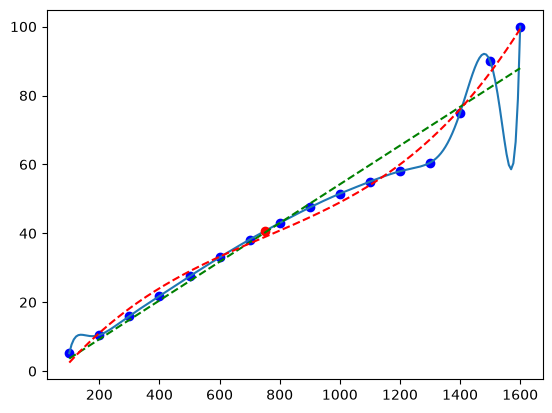

In [ ]:
def plagr(xnodi, j):
    """
    Restituisce i coefficienti del j-esimo polinomio fondamentale
    di Lagrange associato ai nodi contenuti nel vettore xnodi.
    """

    
    xzeri = np.zeros_like(xnodi)

    # n rappresenta il numero di nodi di interpolazione.
    n = xnodi.size

     
    if j == 0:
        xzeri = xnodi[1:n] #to do 
    else:
        xzeri = np.append(xnodi[:j], xnodi[j+1:n]) #to do )

    num = np.poly(xzeri) #to do 
    den = np.polyval(num, xnodi[j]) #to do 

    p = num / den#to do 

    # La funzione restituisce i coefficienti del polinomio L_j(x).
    return p

def InterpL(x, y, xx):
    """
    Funzione che calcola i valori del polinomio interpolante
    di Lagrange in un insieme di punti.

    DATI INPUT:
    x  = vettore contenente i nodi di interpolazione
    y  = vettore contenente i valori della funzione nei nodi
    xx = vettore contenente i punti in cui valutare il polinomio interpolante

    DATI OUTPUT:
    vettore contenente i valori assunti dal polinomio interpolante
    nei punti xx
    """

    # n è il numero di nodi di interpolazione.
    n = x.size

    # m è il numero di punti in cui si vuole valutare il polinomio.
    m = xx.size

     
    L = np.zeros((m, n))

    # Per ogni nodo di interpolazione si costruisce il corrispondente
    # polinomio fondamentale di Lagrange.
    for j in range(n):
        p = plagr(x, j) #to do 
        L[:, j] = np.polyval(p, xx) #to do 

    pol = L @ y #to do       
    return pol

def qrLS(A, b):
    n = A.shape[1]

    # Si calcola la fattorizzazione QR della matrice A.

    Q, R = spl.qr(A)
    h = Q.T @ b
    
    x, _ = st.Usolve(R[0:n, 0:n], h[0:n]) #
    
    residuo = np.linalg.norm(h[n:]) ** 2 #to do 

    # La funzione restituisce i coefficienti della soluzione x
    # e il valore del residuo quadratico.
    return x, residuo

I = np.array([100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0,1400,1500,1600])

P = np.array([5.2, 10.5, 16.0, 21.8, 27.5, 33.0, 38.2, 43.0, 47.5, 51.5, 55.0, 58.0, 60.5,75.0,90,100])

xx = np.linspace(np.min(I), np.max(I), 200)
pol = InterpL(I, P, xx)
plt.plot(I, P, 'ob')
plt.plot(xx, pol)
pol750 = InterpL(I, P, np.array([750]))
print("Potenza stimata: ", pol750)
plt.plot(np.array(750), pol750, 'or')

# Teorema del Resto di Lagrange 
# Dal grafico notiamo che agli estremi la funzione è molto più alterata rispetto all'originale, mentre
# al centro è quasi sovrapposta. Questo perché secondo il teorema di Lagrange, l'errore dipende da tre fattori:
# - quanti nodi ci sono
# - la distanza dei nodi
# - quanto oscilla la funzione originale

# Per la retta di regressione usiamo la matrice di Vandermonde di grado 1 (retta)
vander = np.vander(I, 2)
alpha, residuo = qrLS(vander, P)
polretta = np.polyval(alpha, xx)
plt.plot(xx, polretta, "--g")

# Per la cubica invece stessa cosa di grado 3 (cubico)
vander = np.vander(I, 4)
alpha, residuo = qrLS(vander, P)
polcubica = np.polyval(alpha, xx)
plt.plot(xx, polcubica, "--r")

## Domande IA

## Domande Intelligenza Artificiale
**NB: Ogni risposta esatta:  +0.5 punti, ogni risposta errata: -0.5 punti. La mancanza di risposta:  0 punti**

1- **Risolvere un problema mediante Machine Learning significa**:
- --> Fornire alla macchina i dati affinchè impari da sola a risolvere il problema
- Fornire alla macchina solo dati etichettati affinchè impari da sola a risolvere il problema
- Fornire alla macchina solo dati non etichettati affinchè impari da sola a risolvere il problema
- Fornire alla macchina le esatte istruzioni per risolvere il problema
edizione

   **2**  Quali di queste affermazioni sono vere: 

   --> (a) Un layer di pooling ha l’effetto di ridurre la dimensionalità del volume di input 

   --> (b)  In un layer fully-connected tutti i neuroni di output sono collegati a tutti i valori di input 

   --> (c) In un layer di una rete neurale, il bias è un ulteriore peso apprendibile collegato a un input fittizio con valore sempre 1 

   (d) In una rete Convolutional Neural Network (CNN) i layer di convoluzione sono seguiti da una funzione di attivazione e da un layer fully-connected 

**3.** Quale tra le seguenti affermazioni è FALSA riguardo alla suddivisione del dataset in un contesto di machine learning?

- La suddivisione del dataset in set di training, validation e test è fondamentale per valutare correttamente le prestazioni di un modello di machine learning.
- Il set di training viene utilizzato per addestrare il modello sui dati.
- --> Il set di validation viene utilizzato per trovare le etichette dei dati di input
- Il set di test viene utilizzato per valutare le prestazioni finali del modello su dati che non sono stati utilizzati per il training o la validation.

**4** Quali di queste affermazioni sono vere:

Quando si impiega un’architettura di rete esistente: 

--> (a)  Dato un problema da risolvere, conviene utilizzare un modello con pesi pre-addestrati su un problema simile 

(b) I pesi di un modello pre-addestrato non sono modificabili 

--> (c) È possibile utilizzare un’architettura esistente anche inizializzandone i pesi con valori casuali 

--> (d) Architetture di rete differenti possono raggiungere punteggi di accuratezza simili se addestrate sullo stesso dataset 

--> (e) Architetture di rete differenti possono raggiungere punteggi di accuratezza differenti se addestrate sullo stesso dataset 

**5 Per una rete neurale, l’apprendimento è legato a:**
- --> Minimizzare la funzione obiettivo
- Minimizzare la funzione di attivazione
- Massimizzare il valore dei pesi tramite l’algoritmo di back-propagation
- Massimizzare il valore della funzione di training

# Domande aperte

- Descrivi e confronta le seguenti varianti del metodo di discesa del gradiente utilizzate per ottimizzare la loss function durante l'addestramento di una rete neurale per un task di regressione:

    Discesa del Gradiente (Batch Gradient Descent)
  
    Discesa del Gradiente Stocastico (Stochastic Gradient Descent - SGD)
  
    Discesa del Gradiente a Mini-Batch (Mini-Batch Gradient Descent)
  **Punti 1.5**  
- Descrivi e confronta i seguenti metodi di apprendimento con learing rate adattivo (adaptive learning rate methods) per l'ottimizzazione dei pesi  durante l'addestramento di reti neurali:

    Adagrad
    RMSProp
    Adam

    Per ciascun metodo, illustra la formula di aggiornamento dei pesi e discuti le sue caratteristiche principali, inclusi vantaggi, svantaggi.**[punti 3.0]**

## Risposta 1
18 del pdf

## Risposta 2
22 del pdf